In [1]:
import numpy as np
from hydra_pspec import sys_solver as sys_sol
import matplotlib.pyplot as plt
from pyuvdata import UVData
import scipy as sp
from multiprocess import Pool, current_process
uvd=UVData()

# Loading and checking data

## Getting data from files

In [142]:
def fourier_mode_2d_udf(freqs, times, nfreq, ntime, freq0=None, time0=None, 
                             shape0=None):
    
    """
    Construct a set of 2D Fourier modes from a list of wavenumber integers, 
    to form an incomplete set of 2D Fourier modes.
    """
    # print("Modes: {}".format([ntime,nfreq]))
    freqs=freqs*1e-9

    # Decide on origin of frequency axis for FT
    if time0 is None:
        time0 = times[0]
    if freq0 is None:
        freq0 = freqs[0]

    # Determine normalising factors. If being used as a standalone Fourier operator, 
    # these are just the lengths of the freq and time arrays. If being used as a 
    # chunk of a Fourier operator across multiple workers, use the overall shape 
    # from 'shape0'
    if shape0 is None:
        Nfreqs = freqs.size
        Ntimes = times.size
    else:
        Nfreqs, Ntimes = shape0

    # Build grid of freqs and times
    nfreq = np.atleast_1d(nfreq)
    ntime = np.atleast_1d(ntime)
    assert len(nfreq.shape) == 1
    assert len(ntime.shape) == 1
    assert len(freqs.shape) == 1
    assert len(times.shape) == 1
    t2d, f2d = np.meshgrid(times - time0, freqs - freq0)

    # Calculate wavenumbers for each mode
    kfreq =(2 * np.pi * nfreq)
    ktime = (2 * np.pi * ntime)

    # Shape: (Nmodes, Nfreqs, Ntimes)
    basis_fns = np.exp(1.j \
                        * (  (kfreq[:,np.newaxis,np.newaxis] * f2d[np.newaxis,:,:]) \
                           + (ktime[:,np.newaxis,np.newaxis] * t2d[np.newaxis,:,:])) ) \
              / np.sqrt(Nfreqs * Ntimes)
    return basis_fns

#Function defining the U_sys operator
def h_j_op(freqs,lsts,nm_list):
    '''loop through the nm_list'''
    u=np.array([fourier_mode_2d_udf(freqs,lsts,n,m).flatten() for n,m in nm_list])
    return u.T

In [110]:
dir_path='/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/test_files/divergence_tests_airy_1/'

file_path="/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/hera_val/vis_corrupted_test.uvh5"

uvd=UVData()
uvd.read(file_path)
antpairpols = uvd.get_antpairpols()
vis=uvd.get_data(antpairpols[0], force_copy=True)
freqs=uvd.freq_array[0]
lsts=uvd.lst_array

Telescope Hex37-14.6m is not in known_telescopes.


In [121]:

fgmodes=np.load('test_data/fgmodes.npy')

uvd=UVData()
uvd.read('test_data/vis-eor-fgs.uvh5')
antpairpols = uvd.get_antpairpols()
clean_vis=uvd.get_data(antpairpols[0], force_copy=True)
frac_data=vis/clean_vis

Ntimes=vis.shape[0]
Nfreqs = vis.shape[1] 
Nmodes = fgmodes.shape[1]
Nparams = Nfreqs + Nmodes
flags=np.ones(Nfreqs)

b_sys_past=frac_data[int(Ntimes/2),:]

signal_S=np.load('test_data/eor-cov.npy')
N_cov=np.load('test_data/noise-cov.npy')
Ninv=np.linalg.inv(N_cov)
noise=np.load('test_data/noise.npy')
nm_list=np.loadtxt('nm_list').astype(int)

Bi=np.sqrt(b_sys_past)*np.eye(Nfreqs, dtype='complex')
print("Shape check: \n Visibilities: {}\n flags: {}\n fgmodes: {}\n frac_data: {}\n b_sys_past: {}\n signal_S: {}\n N_cov: {}\n noise: {}\n nm_list: {}\n Binv: {}\n".format(vis.shape,flags.shape,fgmodes.shape,frac_data.shape,b_sys_past.shape,signal_S.shape,N_cov.shape,noise.shape,nm_list.shape,Bi.shape))

Shape check: 
 Visibilities: (203, 120)
 flags: (120,)
 fgmodes: (120, 120)
 frac_data: (203, 120)
 b_sys_past: (120,)
 signal_S: (120, 120)
 N_cov: (120, 120)
 noise: (203, 120)
 nm_list: (120, 2)
 Binv: (120, 120)



Telescope Hex37-14.6m is not in known_telescopes.


In [200]:
h_j = h_j_op(freqs=freqs,lsts=lsts,nm_list=nm_list) #Selecting only 0th time

In [155]:
h_j.shape

(24360, 2)

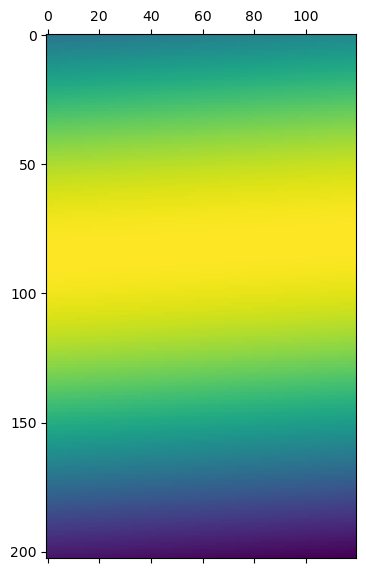

In [161]:
y= h_j @ np.array([0,1])
y=y.reshape([Ntimes,Nfreqs],order='F')
plt.matshow(y.imag,aspect='auto')

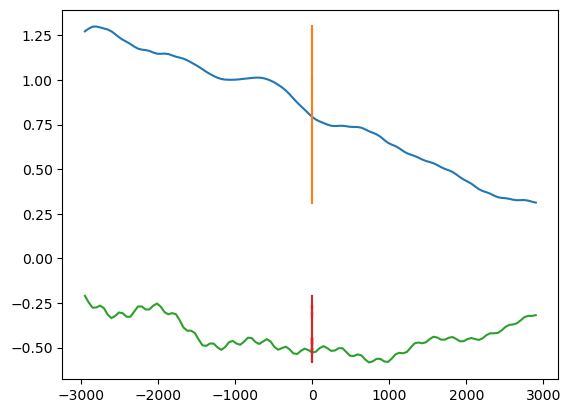

In [203]:
plt.plot(nm_list,b_sys_past.real)
plt.plot(nm_list,b_sys_past.imag)

Casting complex values to real discards the imaginary part
Casting complex values to real discards the imaginary part


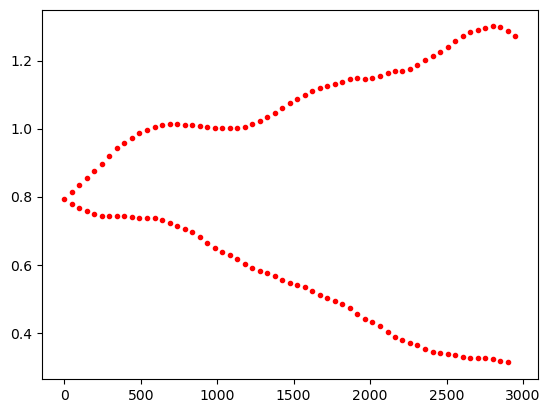

In [187]:
knm = np.sqrt(nm_list[:,0]**2. + nm_list[:,1]**2.)
plt.plot(np.fft.fftshift(knm), np.fft.fftshift(b_sys_past), 'r.')
#plt.plot(np.arange(knm.size), np.fft.fftshift(knm))

In [231]:
# b_sys_past_cut = b_sys_past.copy()
# b_sys_past_cut[:] = 0.
# b_sys_past_cut[59] = 1.
# b_sys_past_cut[56] = 1. + 0.5j
sys_model_past= np.matmul(h_j,b_sys_past)
sys_model_past= np.reshape(sys_model_past, [Ntimes,Nfreqs], order='F')
print("h_j shape: ",h_j.shape,"\nsys_model_past shape: ",sys_model_past.shape)

h_j shape:  (24360, 120) 
sys_model_past shape:  (203, 120)


## Plotting everything

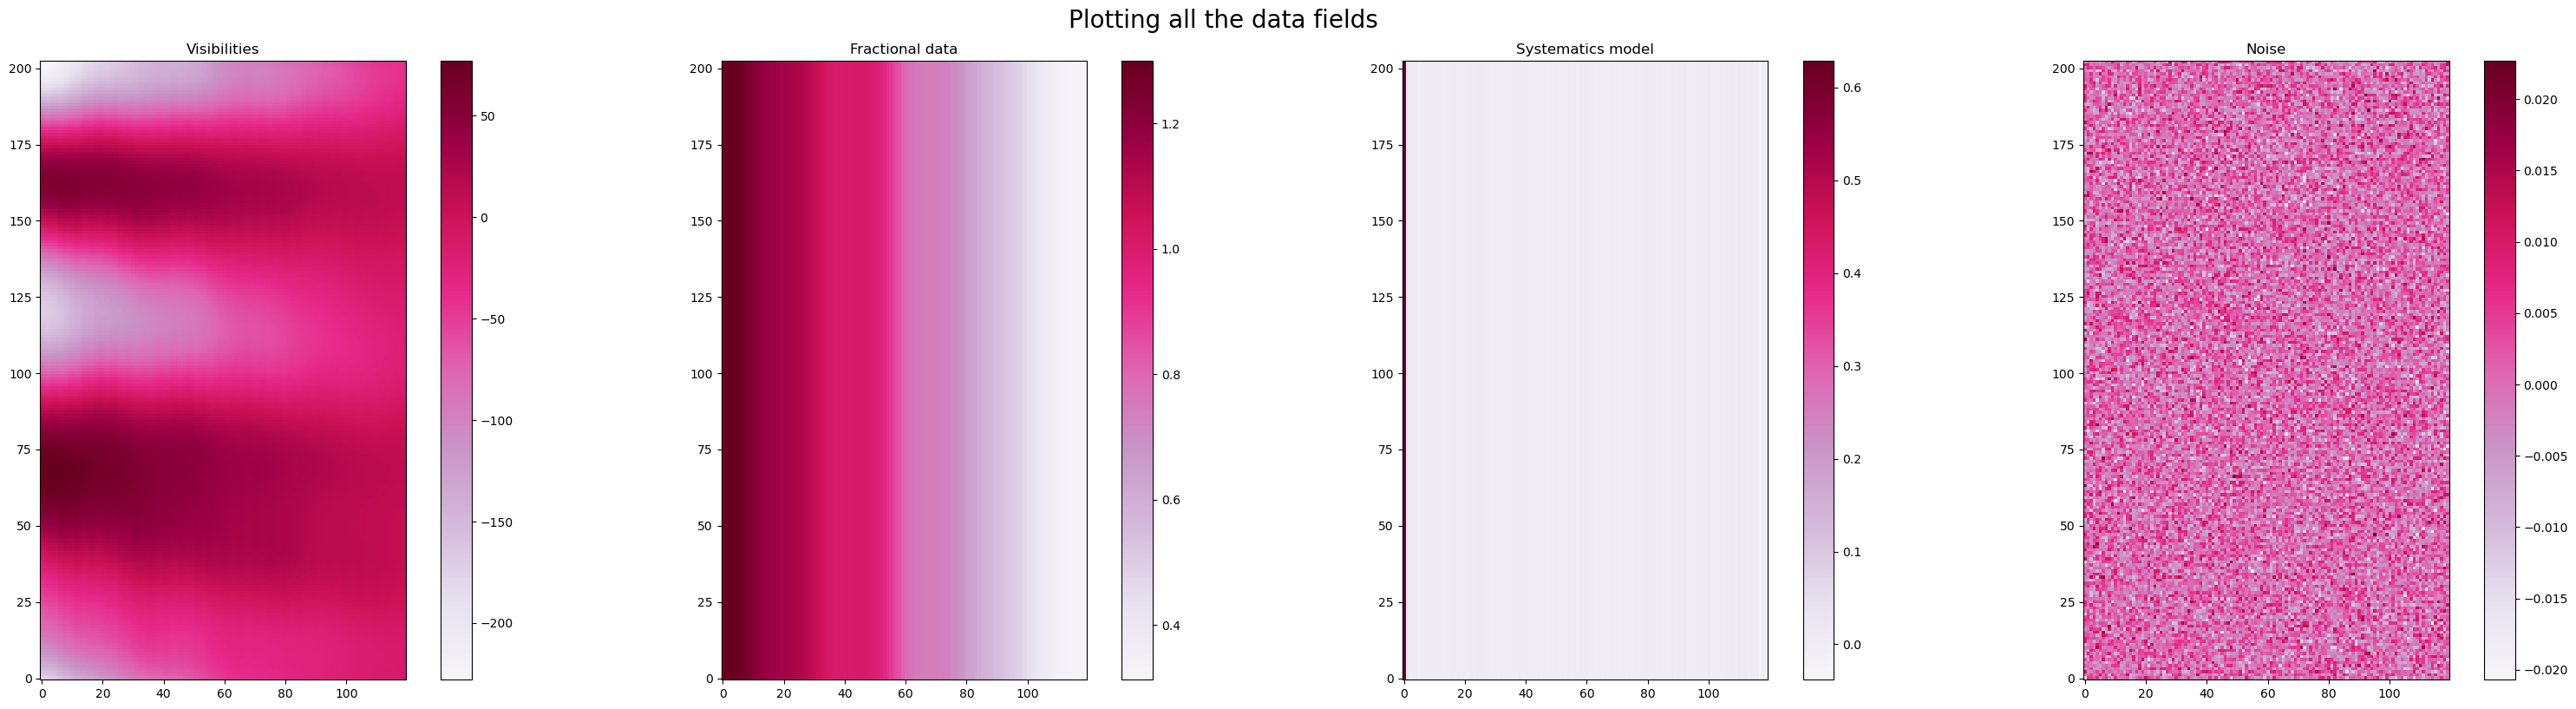

In [232]:
fig, ax= plt.subplots(1, 4, figsize=(32,8))

im0=ax[0].imshow(vis.real, origin='lower',cmap='PuRd')
ax[0].set_title("Visibilities")
plt.colorbar(im0)

im1=ax[1].imshow(frac_data.real, origin='lower',cmap='PuRd')
ax[1].set_title("Fractional data")
plt.colorbar(im1)

im2=ax[2].imshow(sys_model_past.real, origin='lower',cmap='PuRd')
ax[2].set_title("Systematics model")
plt.colorbar(im2)

im3=ax[3].imshow(noise.real, origin='lower',cmap='PuRd')
ax[3].set_title("Noise")
plt.colorbar(im3)

fig.suptitle("Plotting all the data fields",ha='center',va='bottom',fontsize=20)
fig.tight_layout()
fig.subplots_adjust(top=0.94)


Casting complex values to real discards the imaginary part
Casting complex values to real discards the imaginary part


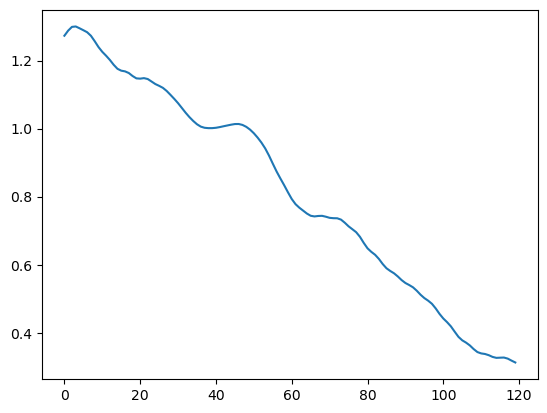

In [165]:
plt.plot(b_sys_past)

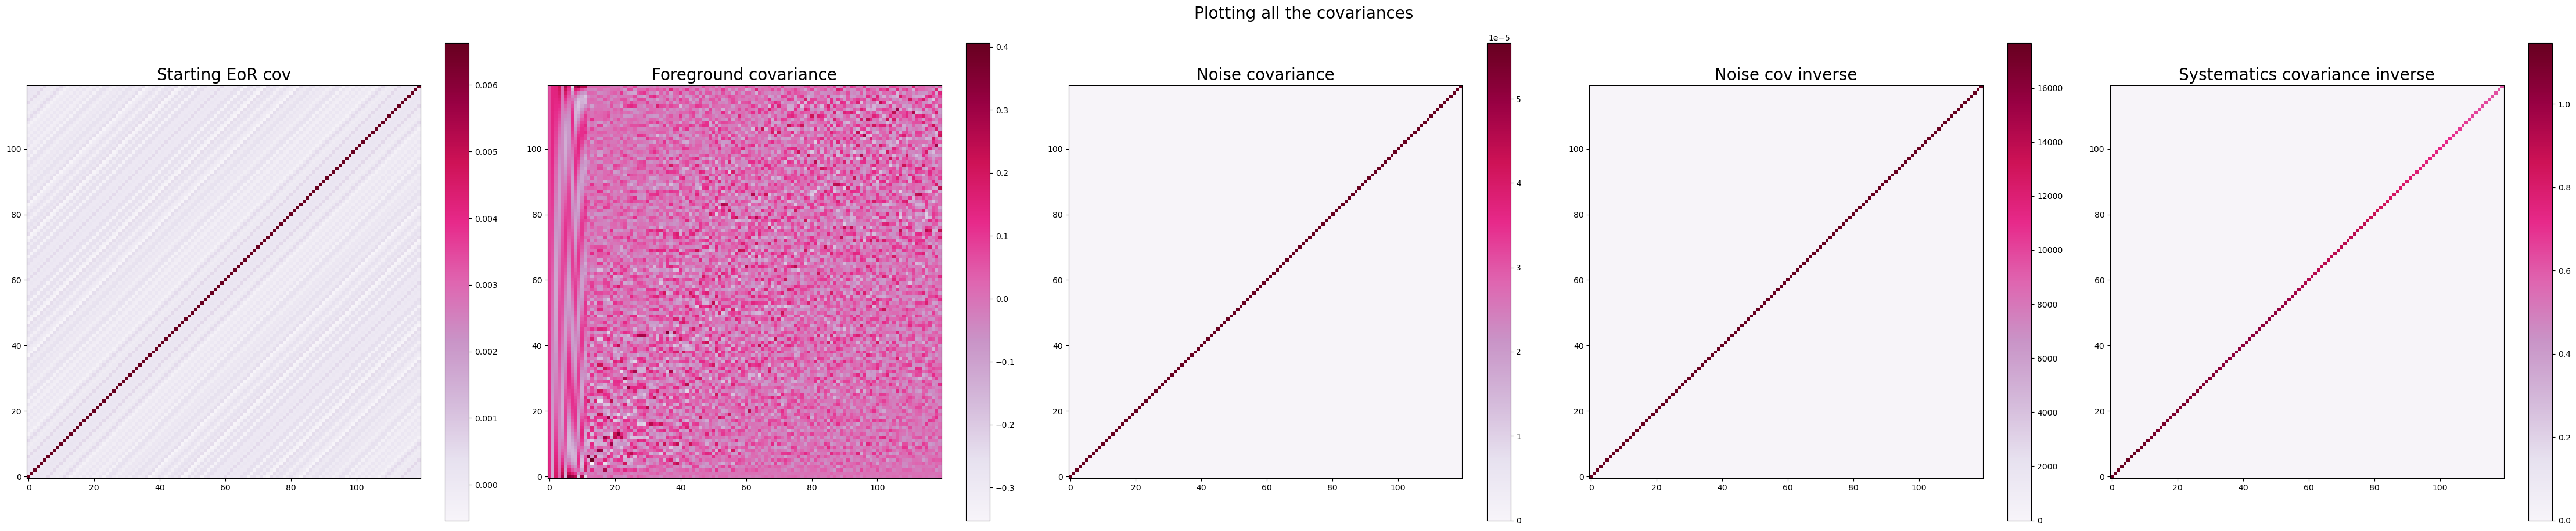

In [ ]:
fig, ax= plt.subplots(1, 5, figsize=(45,9))

im0=ax[0].imshow(signal_S.real, origin='lower',cmap='PuRd')
ax[0].set_title("Starting EoR cov",fontsize=20)
plt.colorbar(im0)

im1=ax[1].imshow(fgmodes.real, origin='lower',cmap='PuRd')
ax[1].set_title("Foreground covariance",fontsize=20)
plt.colorbar(im1)

im2=ax[2].imshow(N_cov.real, origin='lower',cmap='PuRd')
ax[2].set_title("Noise covariance",fontsize=20)
plt.colorbar(im2)

im3=ax[3].imshow(Ninv.real,origin='lower',cmap='PuRd')
ax[3].set_title("Noise cov inverse",fontsize=20)
plt.colorbar(im3)

im4=ax[4].imshow(Bi.real,origin='lower',cmap='PuRd')
ax[4].set_title("Systematics covariance inverse",fontsize=20)
plt.colorbar(im4)

fig.suptitle("Plotting all the covariances",ha='center',va='bottom',fontsize=20)
fig.tight_layout()
fig.subplots_adjust(top=0.94)


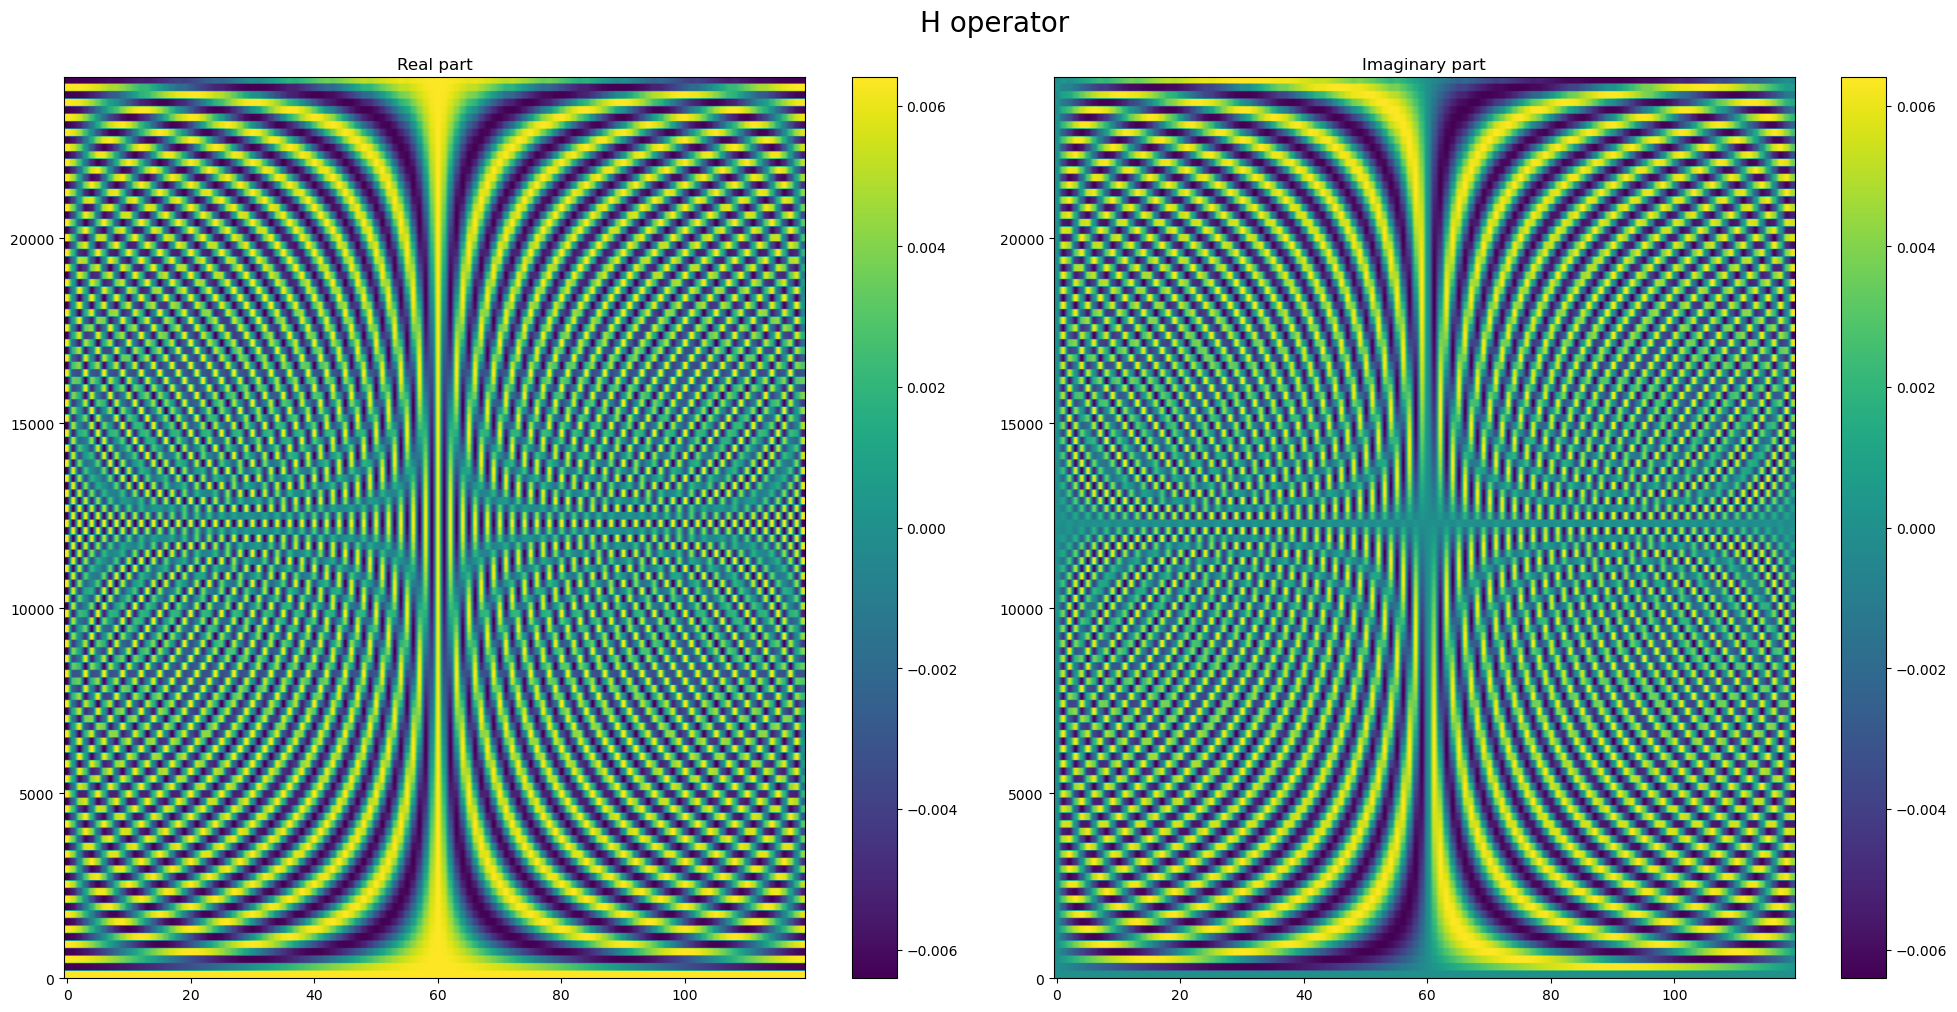

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(20,10))

im0=ax[0].imshow(h_j.real,origin='lower',aspect='auto')
ax[0].set_title('Real part')
plt.colorbar(im0)

im1=ax[1].imshow(h_j.imag,origin='lower',aspect='auto')
ax[1].set_title('Imaginary part')
plt.colorbar(im1)

fig.suptitle("H operator",ha='center',va='bottom',fontsize=20)
fig.tight_layout()
fig.subplots_adjust(top=0.94)

# Before recalculations

## Functions

In [233]:
'''Second modified version of GCR'''
def gcr_fgmodes_1d_v2(idx, vis, w, Nparams, y, flags, E, Ninv, fgmodes, Eh, Nih, f0=None, map_estimate=False, verbose=False,
    multiprocess_seed=912983):

    pid = current_process().pid
    seed = multiprocess_seed + pid*1000 + idx
    np.random.seed(seed)

    Nfreqs, Nmodes = fgmodes.shape
    d = vis.reshape((1, max(Nfreqs, len(vis.T))))

    # Extract precomputed matrices needed by the linear system
    A, Ni, Ai =build_matrices(Nparams, y, flags, E, Ninv, fgmodes)

    if map_estimate:
        oma = np.zeros((Nfreqs, 1), dtype=complex)
        omb = np.zeros((Nfreqs, 1), dtype=complex)
    else:
        # Unit complex Gaussian random realisation
        omi, omj = np.random.randn(Nfreqs, 1), np.random.randn(Nfreqs,1)
        omk, oml = np.random.randn(Nfreqs, 1), np.random.randn(Nfreqs,1)
        oma, omb = (omi + 1.0j * omj) / 2**0.5, (omk + 1.0j * oml) / 2**0.5
    # print("Shapes: \nE:",E.shape,
    #     #   "\ny.conj:",y.conj().shape,
    #     "\nNi: ",Ni.shape,
    #     "\nw:",w.shape,
    #     "\nvis: ",vis.shape,
    #     "\nEh: ",Eh.shape,
    #     "\noma: ",oma.shape,
    #     "\nomb: ",omb.shape,
    #     "\nNih: ",Nih.shape,
    #     "\nfgmodes.T.conj(): ",fgmodes.T.conj().shape,
    #     "\nfgmodes: ",fgmodes.shape,
    #     "\nA: ",A.shape,
    #     "\nd: ",d.shape,
    #     "\ny.conj() * Nih * omb: ",(y.conj()[:,np.newaxis] * Nih[:,np.newaxis] * omb).shape,
    #     "\nNi * w * d: ",(Ni[:,np.newaxis] * w[:,np.newaxis] * d.T).shape)
    # Construct RHS vector
    b = np.zeros((Nfreqs + Nmodes, 1), dtype=complex)
    b[:Nfreqs] = E @ (Ni[:,np.newaxis] * d.T)  #+ Eh @ oma + E @ (y.conj()[:,np.newaxis] * Nih[:,np.newaxis] * omb)  #removing perturbations for test
    b[Nfreqs:] = fgmodes.T.conj() @ (Ni[:,np.newaxis] * d.T)  #+ fgmodes.T.conj() @ (y.conj()[:,np.newaxis] * Nih[:,np.newaxis] * omb) #removing perturbations for test

    # Run CG solver, preconditioned by M=Ai
    x0 = None
    if f0 is not None:
        x0 = np.concatenate((np.zeros(Nfreqs, dtype=complex), f0))
    xsoln, info = sp.sparse.linalg.cgs(A, b, x0=x0, M=Ai, rtol=1e-12) #maxiter=int(1e5)
    if verbose:
        residual = np.abs(A @ xsoln - b[:, 0]).mean()
    else:
        residual = None

    # Return solution vector
    return xsoln, residual, info


'''Second modified version'''
def gcr_fgmodes(
    vis, w, fgmodes, Nparams, sys_model_past, flags, signal_S, Ninv, f0=None, nproc=1, map_estimate=False,
    verbose=False
):
    """
    Perform the GCR step on all time samples, using parallelisation if
    possible.

    Parameters:
        vis (array_like):
            Array of complex visibilities for a single baseline, of shape
            `(Ntimes, Nfreqs)`.
        w (array_like):
            Array of flags or weights (e.g. 1 for unflagged, 0 for flagged).
        matrices (array_like):
            Array containing precomputed matrices needed by the linear system.
        fgmodes (array_like):
            Foreground mode array, of shape (Nfreqs, Nmodes). This should be
            derived from a PCA decomposition of a model foreground covariance
            matrix or similar.
        fourier_op (array_like):
            Pre-computed Fourier operator.
        f0 (array_like):
            Initial guess for the foreground amplitudes, with shape `(Nmodes,)`.
        nproc (int):
            Number of processes to use for parallelised functions.
        map_estimate (bool):
            Provide the maximum a posteriori sample.
        verbose (bool):
            If True, output basic timing stats about each iteration.

    Returns:
        samples (array_like):
            Array of signal + foreground realisations for each time sample,
            of shape `(Ntimes, Nfreqs + Nmodes)`.
    """
    samples = np.zeros((vis.shape[0], vis.shape[1] + fgmodes.shape[1]), dtype=complex)
    if verbose:
        residuals = np.zeros(vis.shape[0], dtype=float)
        info = np.zeros(vis.shape[0], dtype=float)
    else:
        residuals = None
        info = None
    idxs = np.arange(vis.shape[0])
    
    #Time invariant calculations
    Eh=sp.linalg.sqrtm(signal_S)  
    Nih = np.sqrt(np.diag(Ninv))
    
    # Run GCR method on each time sample in parallel
    if verbose:
        st = time.time()
    with Pool(nproc) as pool:
        samples, residuals, info = zip(*pool.map(
            lambda idx: gcr_fgmodes_1d_v2(
                idx=idx,
                vis=vis[idx],
                w=w,
                fgmodes=fgmodes,
                f0=f0,
                Nparams=Nparams,
                y=sys_model_past[idx],
                flags=flags,
                E=signal_S,
                Ninv=Ninv,
                Eh=Eh,
                Nih=Nih,
                map_estimate=map_estimate,
                verbose=verbose
            ),
            idxs,
        )
        )
    samples = np.array(samples).reshape((vis.shape[0], -1))
    residuals = np.array(residuals)
    info = np.array(info)

    # Return sample
    if verbose:
        print(f"{time.time() - st:<12.1f}", end="")
        print(f"{info.mean():<8.1f}", end="")
        print(f"{residuals.mean():<12.2e}", end="")
    return samples


def build_matrices(Nparams, y, flags, E, Ninv, fgmodes):
    """
    Calculate matrices and build A in Ax=b for the GCR step.
    
    Parameters:
        Nparams (int):
            Number of model parameters.
        flags (array_like):
            Array of flags (1 for unflagged, 0 for flagged), with shape 
            `(Nfreqs,)`.
        signal_S (array_like):
            Current value of the EoR signal frequency-frequency covariance.
        Ninv (array_like):
            Inverse noise variance matrix. This can either have shape
            `(Ntimes, Nfreqs, Nfreqs)`, one for each time, or can be a common
            one for all times with shape `(Nfreqs, Nfreqs)`.
        fgmodes (array_like):
            Foreground mode array, of shape (Nfreqs, Nmodes). This should be
            derived from a PCA decomposition of a model foreground covariance
            matrix or similar.
    
    Returns:
        matrices (list of array_like):
            List containing necessary GCR operators (`matrices[0]`) and the
            linear operator A in the GCR Ax=b solve step.
    """
    Nfreqs = E.shape[0]
    
    # Construct necessary operators for GCR
    inner_prod= (y.conj().T * Ninv.diagonal() *  y)
    Ni_flagged = flags.T * (inner_prod) * flags  # Ni # FIXME
    # print("build_matrices shape check:\n y: {}\n flags: {}\n E: {}\n Ninv: {}\n fgmodes: {}\n Ni_flagged: {}".format(y.shape,flags.shape,E.shape,Ninv.shape,fgmodes.shape, Ni_flagged.shape))
    
    # Construct operator matrix
    A = np.zeros((Nparams, Nparams), dtype=complex)
    # print(np.shape(A[Nfreqs:, Nfreqs:]))
    A[:Nfreqs, :Nfreqs] = np.eye(Nfreqs) + E * Ni_flagged[:,np.newaxis]  # 1 + E @ y.dag * Ni * y
    A[:Nfreqs, Nfreqs:] = E @ (Ni_flagged[:,np.newaxis] * fgmodes)
    A[Nfreqs:, :Nfreqs] = (fgmodes.conj() * Ni_flagged[:,np.newaxis]).T
    A[Nfreqs:, Nfreqs:] = fgmodes.T.conj() @ (Ni_flagged[:,np.newaxis] * fgmodes)

    A_pinv = np.linalg.pinv(A)  # pseudo-inverse, to be used as a preconditioner
    
    return A, Ni_flagged, A_pinv

def gcr_sys_v1(Binv,d,Ninv,s,H, b_sys_past=None, verbose=False):
    '''
    Parameters:
    Binv:

    d:
        data (visbilities) flattened to a vector of shape (Nfreqs*Ntimes,)
    N:
        Noise covariance simplified to a vector with shape (Nfreqs*Ntimes,)
    s:
        sky model flattened to a vector of shape (Nfreqs*Ntimes,)
    H:
        Systematics basis functions with shape (Nfreqs*Ntimes,Nmodes)
    '''
    # d_exp=np.concatenate((d.real,d.imag)) #.reshape([-1,1])
    # Bi_diag=0.01
    if verbose:
        st=time.time()
    Ntimes, Nfreqs= d.shape
    d=d.flatten(order='F')
    Binv_diag=np.diag(Binv)
    Binv_exp=np.concatenate((Binv_diag.real,Binv_diag.imag))*np.eye(2*np.shape(Binv)[0])
    diag_el=Ninv[0,0]
    Ninv=diag_el*np.ones(shape=Ntimes*Nfreqs, dtype=complex)  #.reshape([len(d),],order='F')
    Nih=np.sqrt(Ninv)
    # print("Shape of realified matrices: \n d: {},\n Binv: {}\n Nih: {}\n s.real: {}\n s.imag: {}".format(d.shape,Binv_exp.shape,Nih.shape,s.real.shape,s.imag.shape))
    
    '''eq A'''
    Nih_sre=Nih*s.real
    Nih_sim=Nih*s.imag
    
    # print("Shape check 2: \n Nih_sre: {}\n Nih_sim: {}".format(Nih_sre.shape,Nih_sim.shape))
    
    m11= Nih_sre[:,np.newaxis]*H.real - Nih_sim[:,np.newaxis]*H.imag
    m12= -1 *Nih_sre[:,np.newaxis]*H.imag - Nih_sim[:,np.newaxis]*H.real
    # m21= Nih_sim[:,np.newaxis]*H.real + Nih_sre[:,np.newaxis]*H.imag
    # m22= -Nih_sim[:,np.newaxis]*H.imag + Nih_sre[:,np.newaxis]*H.real
    

    nume=np.concatenate((m11,m12),axis=1)
    denom=np.concatenate((-1*m12,m11),axis=1)
    M_tilde=np.concatenate((nume,denom),axis=0)
    # print("Component shape checks: \n m11: {}\n m12: {}\n M_tilde: {}".format(m11.shape,m12.shape,M_tilde.shape))    
    A_mat= Binv_exp + M_tilde.conj().T @ M_tilde # Try einsum as an alternative
    
    nih_dre=Nih*d.real
    nih_dim=Nih*d.imag
    
    nume= m11.T @ nih_dre + -1 * m12.T @nih_dim
    denom= m12.T @ nih_dre + m11.T @ nih_dim
    
    b_mat= np.concatenate((nume, denom), axis=0)
    
    # print("Shape checks: \n A_mat: {}\n b_mat: {}".format(A_mat.shape,b_mat.shape))
    
    if b_sys_past is not None:
        x0=np.concatenate([b_sys_past.real,b_sys_past.imag],axis=0)
    b_sys,info=sp.sparse.linalg.cgs(A_mat,b_mat,tol=1e-12)
    residuals = np.abs(A_mat @ b_sys - b_mat).mean()
    b_sys=b_sys[int(len(b_sys)/2):] + 1.j* b_sys[:int(len(b_sys)/2)]

    if verbose:
        print(f"{time.time() - st:<12.1f}", end="")
        print(f"{info:<8.1f}", end="")
        print(f"{residuals:<12.2e}", end="")
    
    
    return b_sys

## Running solvers

In [234]:
cr=gcr_fgmodes(
    vis=vis*flags, w=flags, fgmodes=fgmodes, Nparams=Nparams, sys_model_past=frac_data, flags=flags, signal_S=signal_S, Ninv=Ninv, f0=None, nproc=1, map_estimate=False,
    verbose=False
)

In [235]:
signal_cr = cr[:, : -fgmodes.shape[1]]
fg_amps = cr[:, -fgmodes.shape[1] :]

model = (signal_cr + fg_amps @ fgmodes.T)
print("Shape check: \n signal_cr: {}\n fg_amps: {}\n model: {}\n".format(signal_cr.shape,fg_amps.shape,model.shape))

Shape check: 
 signal_cr: (203, 120)
 fg_amps: (203, 120)
 model: (203, 120)



In [236]:
b_sys=sys_sol.gcr_sys_v1(Binv=Bi,d=vis*flags,Ninv=Ninv,s=model.flatten('F'),H=h_j,b_sys_past=b_sys_past,verbose=True)

0.5         0.0     5.76e-04    

In [237]:
sys_model=h_j @ b_sys
sys_model= np.reshape(sys_model, [Ntimes,Nfreqs], order='F')

## Plotting and comparing solutions

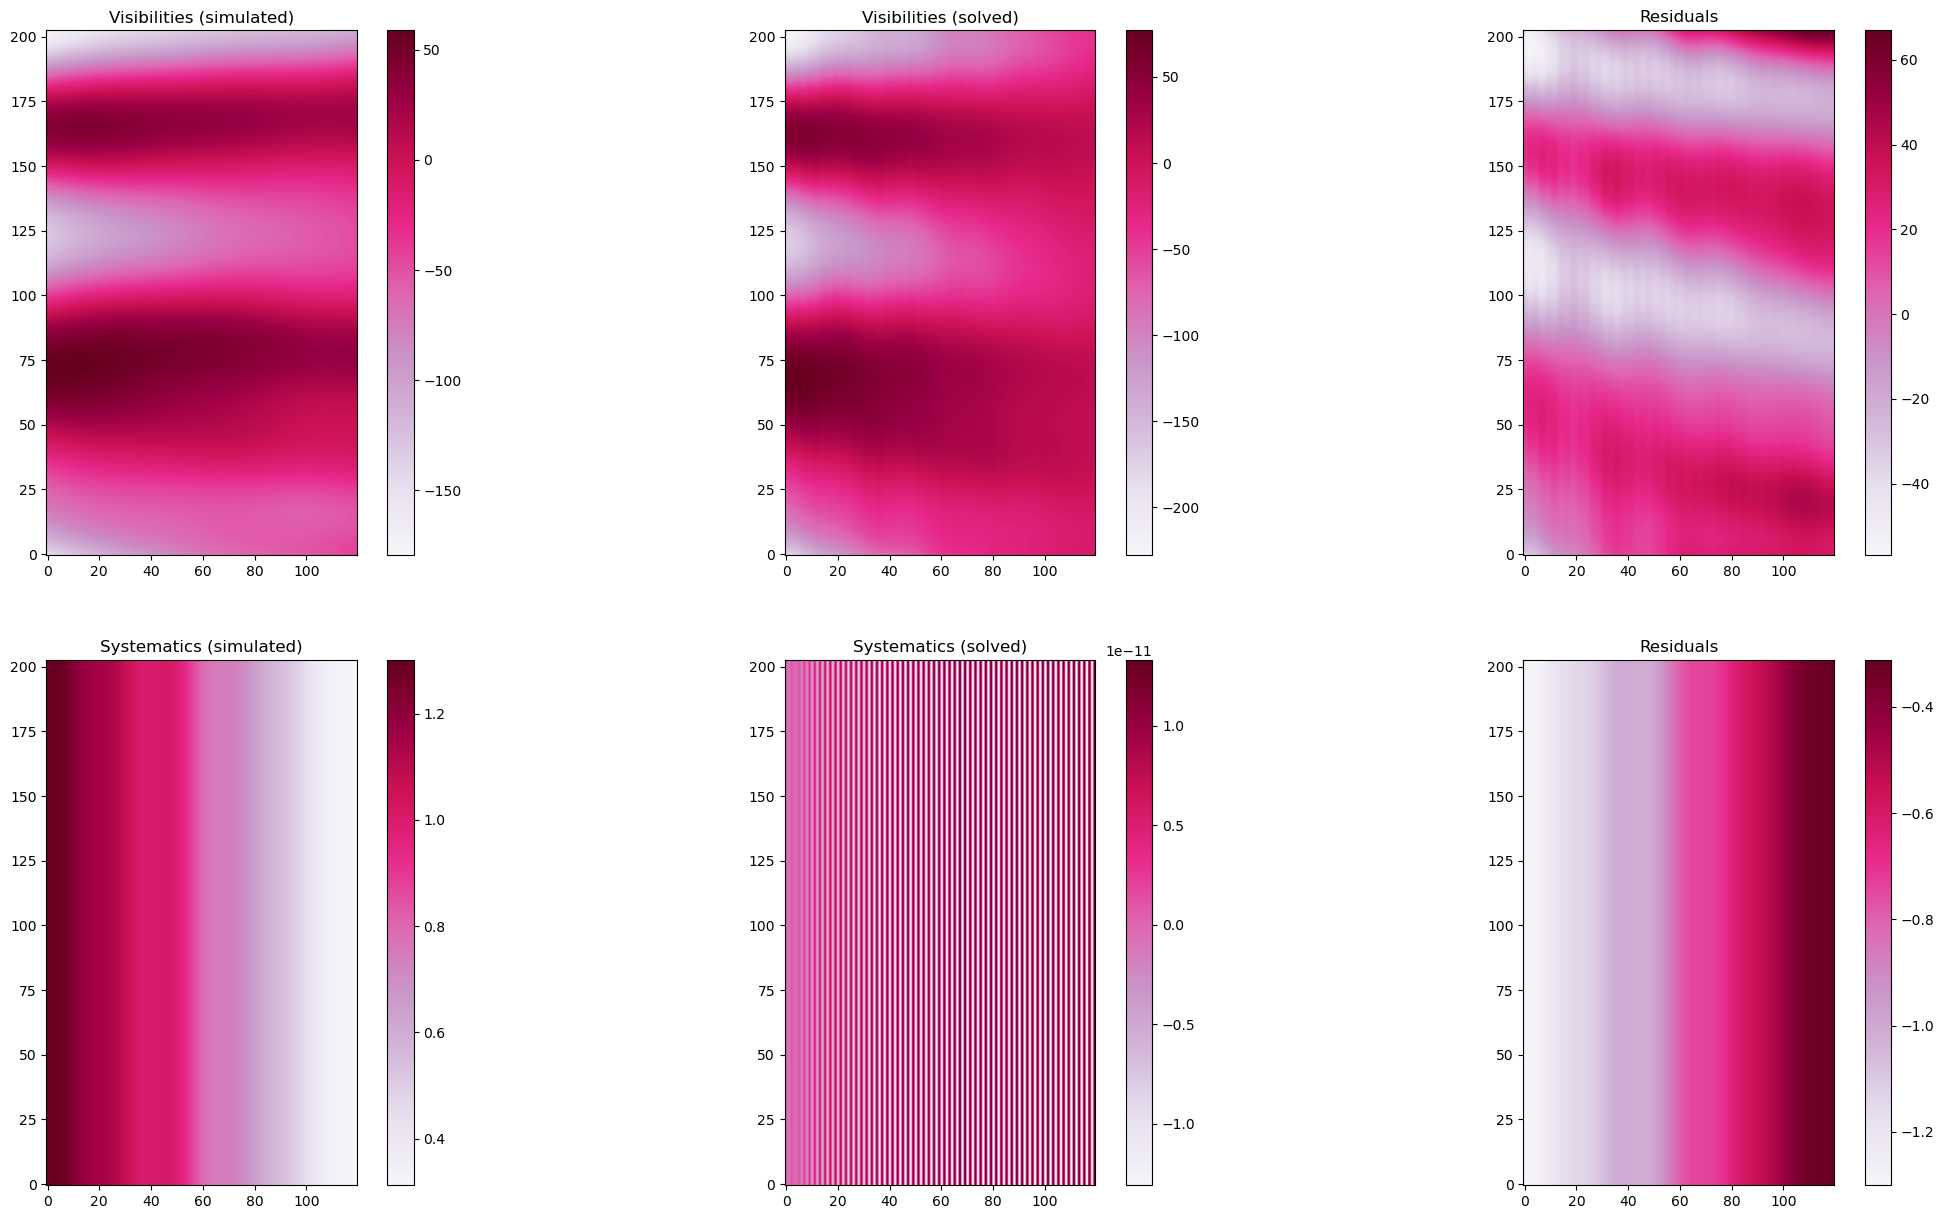

In [238]:
fig, ax= plt.subplots(2,3,figsize=(27,15))

im0=ax[0,0].imshow(clean_vis.real,origin='lower',cmap='PuRd')
ax[0,0].set_title('Visibilities (simulated)')
plt.colorbar(im0)

im1=ax[0,1].imshow(model.real,origin='lower',cmap='PuRd')
ax[0,1].set_title('Visibilities (solved)')
plt.colorbar(im1)

im2=ax[0,2].imshow((model-clean_vis).real,origin='lower',cmap='PuRd')
ax[0,2].set_title('Residuals')
plt.colorbar(im2)

im3=ax[1,0].imshow(frac_data.real,origin='lower',cmap='PuRd')
ax[1,0].set_title('Systematics (simulated)')
plt.colorbar(im3)

im4=ax[1,1].imshow(sys_model.real,origin='lower',cmap='PuRd')
ax[1,1].set_title('Systematics (solved)')
plt.colorbar(im4)

im5=ax[1,2].imshow((sys_model-frac_data).real,origin='lower',cmap='PuRd')
ax[1,2].set_title('Residuals')
plt.colorbar(im5)

# After recalculations

## Functions

In [77]:
'''Second modified version of GCR'''
def gcr_fgmodes_1d_v2(idx, vis, w, Nparams, y, flags, E, Ninv, fgmodes, Eh, Nih, f0=None, map_estimate=False, verbose=False,
    multiprocess_seed=912983):

    pid = current_process().pid
    seed = multiprocess_seed + pid*1000 + idx
    np.random.seed(seed)

    Nfreqs, Nmodes = fgmodes.shape
    d = vis.reshape((1, max(Nfreqs, len(vis.T))))

    # Extract precomputed matrices needed by the linear system
    A, Ni, Ai =build_matrices(Nparams, y, flags, E, Ninv, fgmodes)

    if map_estimate:
        oma = np.zeros((Nfreqs, 1), dtype=complex)
        omb = np.zeros((Nfreqs, 1), dtype=complex)
    else:
        # Unit complex Gaussian random realisation
        omi, omj = np.random.randn(Nfreqs, 1), np.random.randn(Nfreqs,1)
        omk, oml = np.random.randn(Nfreqs, 1), np.random.randn(Nfreqs,1)
        oma, omb = (omi + 1.0j * omj) / 2**0.5, (omk + 1.0j * oml) / 2**0.5
    # print("Shapes: \nE:",E.shape,
    #     #   "\ny.conj:",y.conj().shape,
    #     "\nNi: ",Ni.shape,
    #     "\nw:",w.shape,
    #     "\nvis: ",vis.shape,
    #     "\nEh: ",Eh.shape,
    #     "\noma: ",oma.shape,
    #     "\nomb: ",omb.shape,
    #     "\nNih: ",Nih.shape,
    #     "\nfgmodes.T.conj(): ",fgmodes.T.conj().shape,
    #     "\nfgmodes: ",fgmodes.shape,
    #     "\nA: ",A.shape,
    #     "\nd: ",d.shape,
    #     "\ny.conj() * Nih * omb: ",(y.conj()[:,np.newaxis] * Nih[:,np.newaxis] * omb).shape,
    #     "\nNi * w * d: ",(Ni[:,np.newaxis] * w[:,np.newaxis] * d.T).shape)
    # Construct RHS vector
    b = np.zeros((Nfreqs + Nmodes, 1), dtype=complex)
    b[:Nfreqs] = (y.conj()[:,np.newaxis] * Ni[:,np.newaxis] * d.T) + y.conj()[:,np.newaxis] * Eh @ oma + (y.conj()[:,np.newaxis] * Nih[:,np.newaxis] * omb)
    b[Nfreqs:] = fgmodes.T.conj() @ (y.conj()[:,np.newaxis] * Ni[:,np.newaxis] * d.T) + fgmodes.T.conj() @ (y.conj()[:,np.newaxis] * Nih[:,np.newaxis] * omb)

    # Run CG solver, preconditioned by M=Ai
    x0 = None
    if f0 is not None:
        x0 = np.concatenate((np.zeros(Nfreqs, dtype=complex), f0))
    xsoln, info = sp.sparse.linalg.cgs(A, b, x0=x0, M=Ai, rtol=1e-12) #maxiter=int(1e5)
    if verbose:
        residual = np.abs(A @ xsoln - b[:, 0]).mean()
    else:
        residual = None

    # Return solution vector
    return xsoln, residual, info


'''Second modified version'''
def gcr_fgmodes(
    vis, w, fgmodes, Nparams, sys_model_past, flags, signal_S, Ninv, f0=None, nproc=1, map_estimate=False,
    verbose=False
):
    """
    Perform the GCR step on all time samples, using parallelisation if
    possible.

    Parameters:
        vis (array_like):
            Array of complex visibilities for a single baseline, of shape
            `(Ntimes, Nfreqs)`.
        w (array_like):
            Array of flags or weights (e.g. 1 for unflagged, 0 for flagged).
        matrices (array_like):
            Array containing precomputed matrices needed by the linear system.
        fgmodes (array_like):
            Foreground mode array, of shape (Nfreqs, Nmodes). This should be
            derived from a PCA decomposition of a model foreground covariance
            matrix or similar.
        fourier_op (array_like):
            Pre-computed Fourier operator.
        f0 (array_like):
            Initial guess for the foreground amplitudes, with shape `(Nmodes,)`.
        nproc (int):
            Number of processes to use for parallelised functions.
        map_estimate (bool):
            Provide the maximum a posteriori sample.
        verbose (bool):
            If True, output basic timing stats about each iteration.

    Returns:
        samples (array_like):
            Array of signal + foreground realisations for each time sample,
            of shape `(Ntimes, Nfreqs + Nmodes)`.
    """
    samples = np.zeros((vis.shape[0], vis.shape[1] + fgmodes.shape[1]), dtype=complex)
    if verbose:
        residuals = np.zeros(vis.shape[0], dtype=float)
        info = np.zeros(vis.shape[0], dtype=float)
    else:
        residuals = None
        info = None
    idxs = np.arange(vis.shape[0])
    
    #Time invariant calculations
    Eh=sp.linalg.sqrtm(signal_S)  
    Nih = np.sqrt(np.diag(Ninv))
    
    # Run GCR method on each time sample in parallel
    if verbose:
        st = time.time()
    with Pool(nproc) as pool:
        samples, residuals, info = zip(*pool.map(
            lambda idx: gcr_fgmodes_1d_v2(
                idx=idx,
                vis=vis[idx],
                w=w,
                fgmodes=fgmodes,
                f0=f0,
                Nparams=Nparams,
                y=sys_model_past[idx],
                flags=flags,
                E=signal_S,
                Ninv=Ninv,
                Eh=Eh,
                Nih=Nih,
                map_estimate=map_estimate,
                verbose=verbose
            ),
            idxs,
        )
        )
    samples = np.array(samples).reshape((vis.shape[0], -1))
    residuals = np.array(residuals)
    info = np.array(info)

    # Return sample
    if verbose:
        print(f"{time.time() - st:<12.1f}", end="")
        print(f"{info.mean():<8.1f}", end="")
        print(f"{residuals.mean():<12.2e}", end="")
    return samples


def build_matrices(Nparams, y, flags, E, Ninv, fgmodes):
    """
    Calculate matrices and build A in Ax=b for the GCR step.
    
    Parameters:
        Nparams (int):
            Number of model parameters.
        flags (array_like):
            Array of flags (1 for unflagged, 0 for flagged), with shape 
            `(Nfreqs,)`.
        signal_S (array_like):
            Current value of the EoR signal frequency-frequency covariance.
        Ninv (array_like):
            Inverse noise variance matrix. This can either have shape
            `(Ntimes, Nfreqs, Nfreqs)`, one for each time, or can be a common
            one for all times with shape `(Nfreqs, Nfreqs)`.
        fgmodes (array_like):
            Foreground mode array, of shape (Nfreqs, Nmodes). This should be
            derived from a PCA decomposition of a model foreground covariance
            matrix or similar.
    
    Returns:
        matrices (list of array_like):
            List containing necessary GCR operators (`matrices[0]`) and the
            linear operator A in the GCR Ax=b solve step.
    """
    Nfreqs = E.shape[0]
    
    E_inv=np.linalg.inv(E) #FIXME
    # G_inv=np.linalg.inv(fgmodes) #FIXME
    
    # Construct necessary operators for GCR
    inner_prod= (y.conj().T * Ninv.diagonal() *  y)
    Ni_flagged = flags.T * (inner_prod) * flags  # Ni # FIXME
    # print("build_matrices shape check:\n y: {}\n flags: {}\n signal_S: {}\n Ninv: {}\n fgmodes: {}\n Ni_flagged: {}".format(y.shape,flags.shape,E.shape,Ninv.shape,fgmodes.shape, Ni_flagged.shape))
    
    # Construct operator matrix
    A = np.zeros((Nparams, Nparams), dtype=complex)
    A[:Nfreqs, :Nfreqs] = y.conj()[:,np.newaxis] * E_inv * y[:,np.newaxis] + Ni_flagged  # A11: y.dag E^-1 y + y.dag * Ni * y
    A[:Nfreqs, Nfreqs:] = Ni_flagged[:,np.newaxis] * fgmodes # A12: y.dag * Ni * y * G
    A[Nfreqs:, :Nfreqs] = (fgmodes.conj() * Ni_flagged[:,np.newaxis]).T #A21: G.dag * y.dag * Ni * y
    A[Nfreqs:, Nfreqs:] = fgmodes.T.conj() @ (Ni_flagged[:,np.newaxis] * fgmodes) #A22: y.dag * G^-1 *y + G.dag * y.dag * Ni * y * G (y.conj()[:,np.newaxis] * G_inv * y[:,np.newaxis] + )

    A_pinv = np.linalg.pinv(A)  # pseudo-inverse, to be used as a preconditioner
    
    return A, Ni_flagged, A_pinv
    

def gcr_sys_v1(Binv,d,Ninv,s,H, b_sys_past=None, verbose=False):
    '''
    Parameters:
    Binv:

    d:
        data (visbilities) flattened to a vector of shape (Nfreqs*Ntimes,)
    N:
        Noise covariance simplified to a vector with shape (Nfreqs*Ntimes,)
    s:
        sky model flattened to a vector of shape (Nfreqs*Ntimes,)
    H:
        Systematics basis functions with shape (Nfreqs*Ntimes,Nmodes)
    '''
    # d_exp=np.concatenate((d.real,d.imag)) #.reshape([-1,1])
    # Bi_diag=0.01
    if verbose:
        st=time.time()
    Ntimes, Nfreqs= d.shape
    d=d.flatten(order='F')
    Binv_diag=np.diag(Binv)
    Binv_exp=np.concatenate((Binv_diag.real,Binv_diag.imag))*np.eye(2*np.shape(Binv)[0])
    diag_el=Ninv[0,0]
    Ninv=diag_el*np.ones(shape=Ntimes*Nfreqs, dtype=complex)  #.reshape([len(d),],order='F')
    Nih=np.sqrt(Ninv)
    # print("Shape of realified matrices: \n d: {},\n Binv: {}\n Nih: {}\n s.real: {}\n s.imag: {}".format(d.shape,Binv_exp.shape,Nih.shape,s.real.shape,s.imag.shape))
    
    '''eq A'''
    Nih_sre=Nih*s.real
    Nih_sim=Nih*s.imag
    
    # print("Shape check 2: \n Nih_sre: {}\n Nih_sim: {}".format(Nih_sre.shape,Nih_sim.shape))
    
    m11= Nih_sre[:,np.newaxis]*H.real - Nih_sim[:,np.newaxis]*H.imag
    m12= -1 *Nih_sre[:,np.newaxis]*H.imag - Nih_sim[:,np.newaxis]*H.real
    # m21= Nih_sim[:,np.newaxis]*H.real + Nih_sre[:,np.newaxis]*H.imag
    # m22= -Nih_sim[:,np.newaxis]*H.imag + Nih_sre[:,np.newaxis]*H.real
    

    nume=np.concatenate((m11,m12),axis=1)
    denom=np.concatenate((-1*m12,m11),axis=1)
    M_tilde=np.concatenate((nume,denom),axis=0)
    # print("Component shape checks: \n m11: {}\n m12: {}\n M_tilde: {}".format(m11.shape,m12.shape,M_tilde.shape))    
    A_mat= Binv_exp + M_tilde.conj().T @ M_tilde # Try einsum as an alternative
    
    nih_dre=Nih*d.real
    nih_dim=Nih*d.imag
    
    nume= m11.T @ nih_dre + -1 * m12.T @nih_dim
    denom= m12.T @ nih_dre + m11.T @ nih_dim
    
    b_mat= np.concatenate((nume, denom), axis=0)
    
    # print("Shape checks: \n A_mat: {}\n b_mat: {}".format(A_mat.shape,b_mat.shape))
    
    if b_sys_past is not None:
        x0=np.concatenate([b_sys_past.real,b_sys_past.imag],axis=0)
    b_sys,info=sp.sparse.linalg.cgs(A_mat,b_mat,tol=1e-12)
    residuals = np.abs(A_mat @ b_sys - b_mat).mean()
    b_sys=b_sys[int(len(b_sys)/2):] + 1.j* b_sys[:int(len(b_sys)/2)]

    if verbose:
        print(f"{time.time() - st:<12.1f}", end="")
        print(f"{info:<8.1f}", end="")
        print(f"{residuals:<12.2e}", end="")
    
    
    return b_sys

## Running solvers

In [78]:
cr=gcr_fgmodes(
    vis=vis * flags, w=flags, fgmodes=fgmodes, Nparams=Nparams, sys_model_past=frac_data, flags=flags, signal_S=signal_S, Ninv=Ninv, f0=None, nproc=1, map_estimate=False,
    verbose=False
)

In [79]:
signal_cr = cr[:, : -fgmodes.shape[1]]
fg_amps = cr[:, -fgmodes.shape[1] :]

model = (signal_cr + fg_amps @ fgmodes.T)
print("Shape check: \n signal_cr: {}\n fg_amps: {}\n model: {}\n".format(signal_cr.shape,fg_amps.shape,model.shape))

Shape check: 
 signal_cr: (203, 120)
 fg_amps: (203, 120)
 model: (203, 120)



In [80]:
b_sys=sys_sol.gcr_sys_v1(Binv=Bi,d=vis * flags,Ninv=Ninv,s=model.flatten('F'),H=h_j,b_sys_past=b_sys_past,verbose=True)

0.5         0.0     8.01e-04    

In [81]:
sys_model=h_j @ b_sys
sys_model= np.reshape(sys_model, [Ntimes,Nfreqs], order='F')

## Plotting and comparing solutions

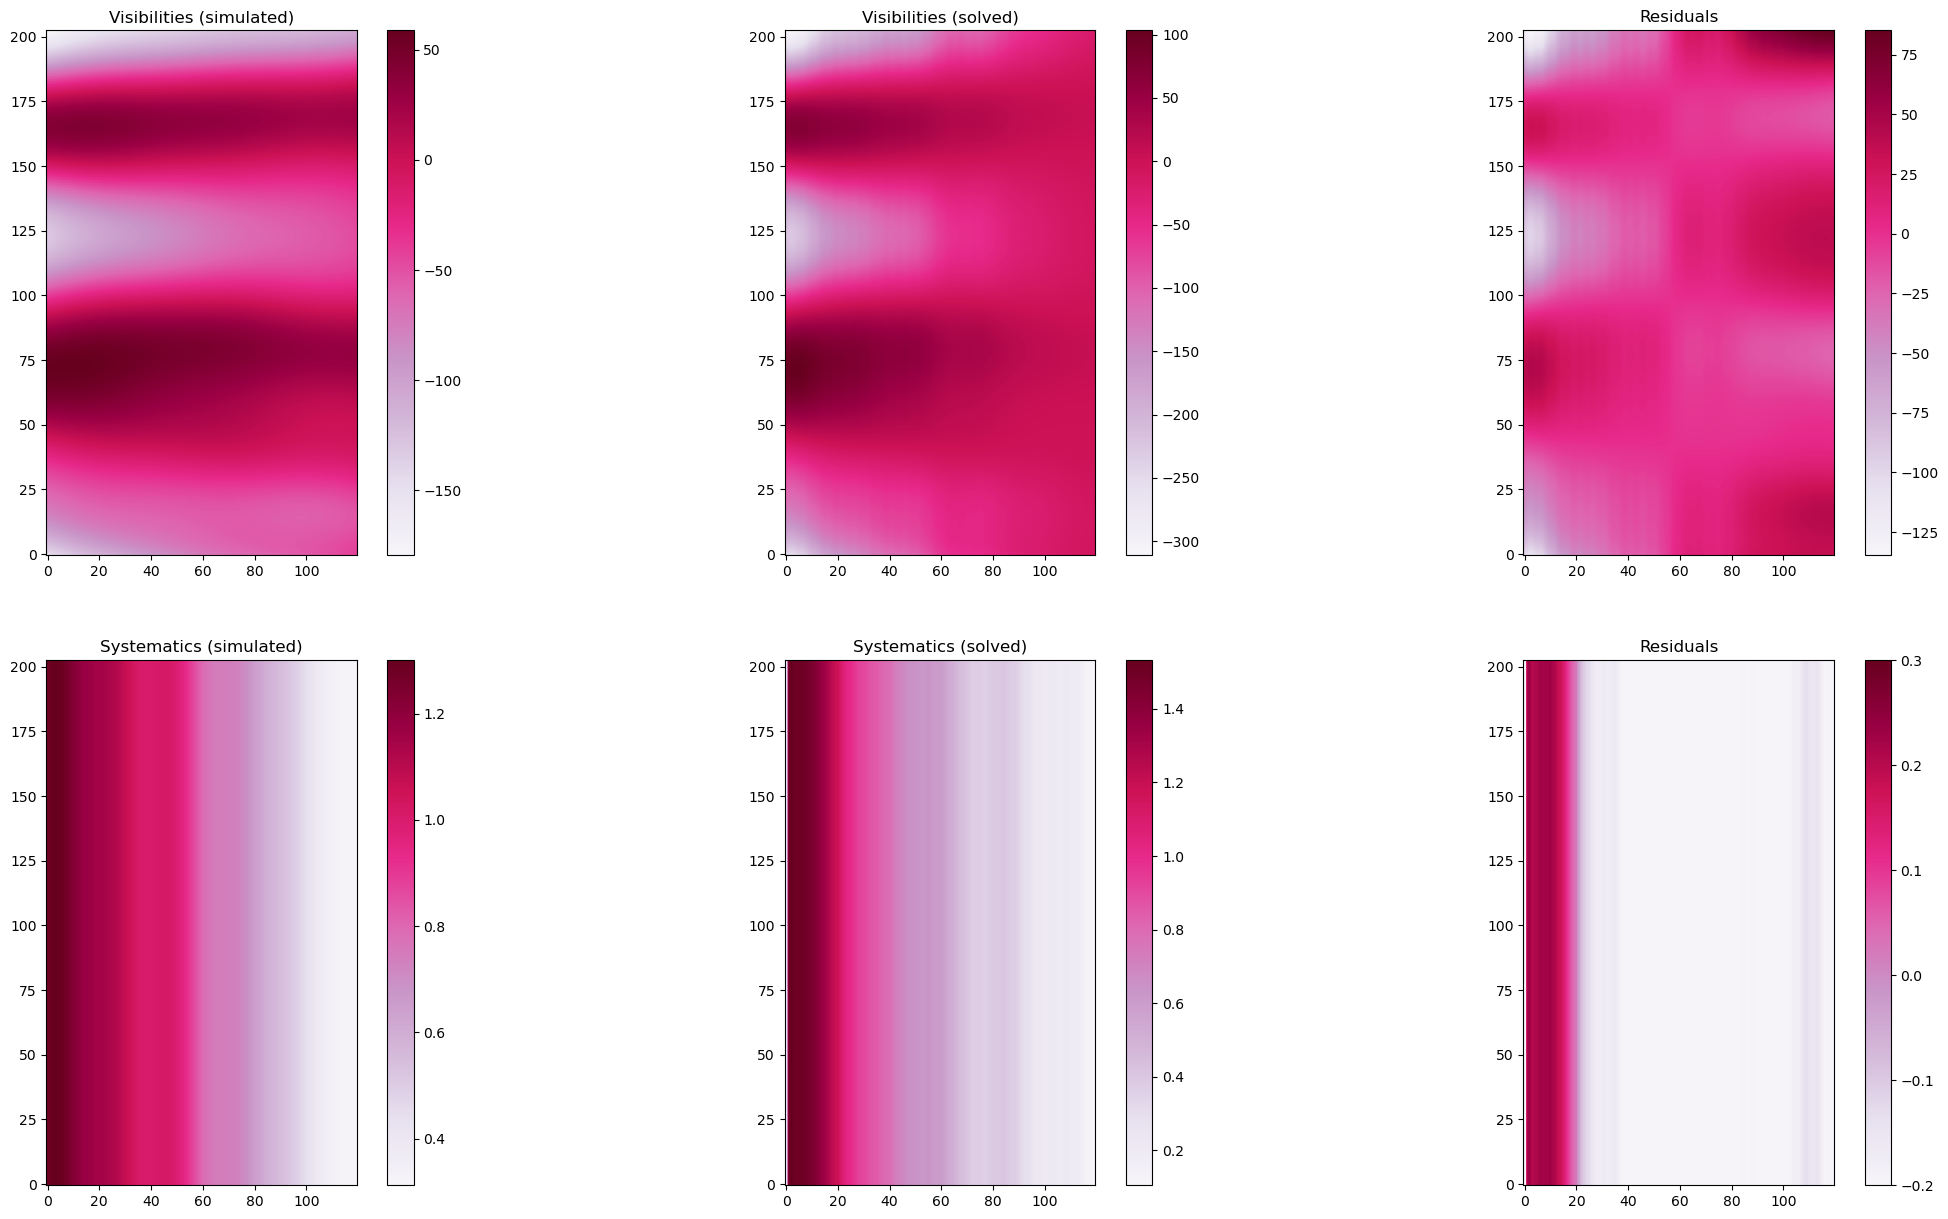

In [85]:
fig, ax= plt.subplots(2,3,figsize=(27,15))

im0=ax[0,0].imshow(clean_vis.real,origin='lower',cmap='PuRd')
ax[0,0].set_title('Visibilities (simulated)')
plt.colorbar(im0)

im1=ax[0,1].imshow(model.real,origin='lower',cmap='PuRd')
ax[0,1].set_title('Visibilities (solved)')
plt.colorbar(im1)

im2=ax[0,2].imshow((model-clean_vis).real,origin='lower',cmap='PuRd')
ax[0,2].set_title('Residuals')
plt.colorbar(im2)

im3=ax[1,0].imshow(frac_data.real,origin='lower',cmap='PuRd')
ax[1,0].set_title('Systematics (simulated)')
plt.colorbar(im3)

im4=ax[1,1].imshow(-1*sys_model.real,origin='lower',cmap='PuRd')
ax[1,1].set_title('Systematics (solved)')
plt.colorbar(im4)

im5=ax[1,2].imshow((-1*sys_model-frac_data).real,origin='lower',cmap='PuRd',vmin=-0.2,vmax=0.3)
ax[1,2].set_title('Residuals')
plt.colorbar(im5)